In [15]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jrd
import jax.numpy as jnp
from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.landscape_visuals import *
from evoscape.jax import pytree_to_landscape
from evoscape.jax.regimes import mr_const
from evoscape.jax.dynamics import get_cell_states
from evoscape.jax.losses import origin_leading_fitness, biseparating_fitness
from evoscape.jax.experiment import Experiment
from evoscape.jax.utils import init_cell, make_movie_landscape
from jax.scipy.special import kl_div, entr
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# Landscape with one regime + simple visualization
%autoreload

# Definition of the modules of the landscape: to be constructed accordingly

# M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
# M2 = Node(x=3., y=0., a=2., s=0.8)


M1 = Node(x=-0.5, y=0., a=1.5, s=1.)
M2 = Node(x=0.5, y=0., a=2., s=0.8)

module_list = [M1, M2]


# M1 = Node(x=-3., y=0., a=3., s=1.)
# M2 = Node(x=4., y=0., a=3., s=1.)
# M3 = Node (x= 2., y= 3., a= 3.,s=1.)

# module_list = [M1, M2,M3]

for M in module_list:
    print(M)

# Definition of the landscape
landscape = Landscape(module_list, A0 = 0.01, regime=mr_const, n_regimes=1)
print(landscape)


#Numerical constants for simulation
n, init_cond, cell_noise, t0,tf, nt, ndt, noise, steps=200, jnp.array([0.,1.]), 0.5, 0., 10., 51, 50, 0.5, 275

q_init = jnp.tile(init_cond[:, None], (1, n))

# Selection of the get_states function 
get_states = get_cell_states


T, μ, λ, q_prob =1., 20., 100., (0.4,0.6)

loss_params = T, μ, λ, q_prob
fitness = biseparating_fitness
# For signal regime
signal_param = None

Node: x=-0.5; y=0.0; a=1.5; s=1.
Node: x=0.5; y=0.0; a=2.; s=0.8
Landscape with modules:
Node: x=-0.5; y=0.0; a=1.5; s=1.,
Node: x=0.5; y=0.0; a=2.; s=0.8


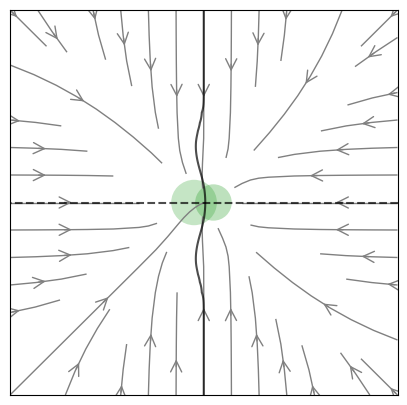

In [17]:
# Parameters of vizualisation 
L = 10.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

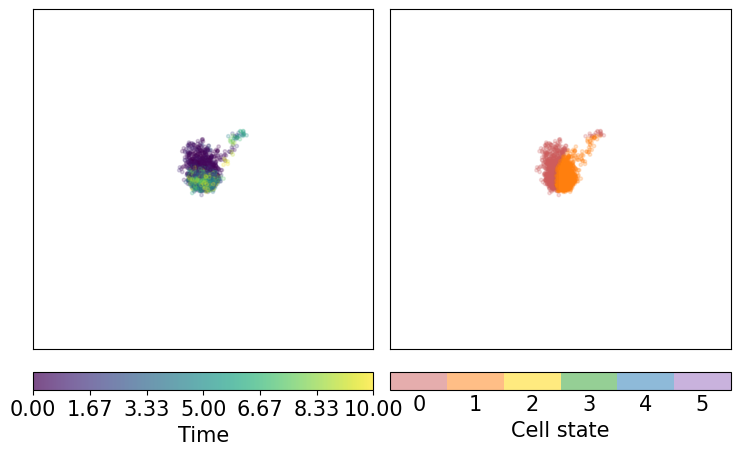

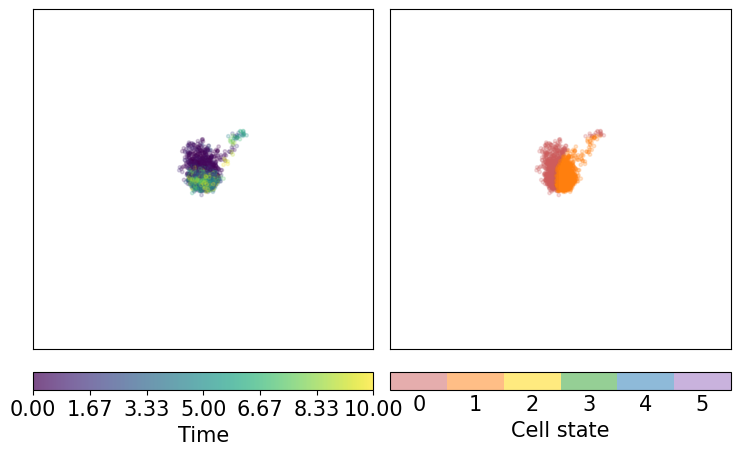

In [18]:
landscape.init_cells(n,landscape.init_cond,noise=cell_noise)
get_and_plot_traj(landscape,t0,tf,nt,L,noise)

In [19]:
# n_frames = 100
# time_pars = (t0,tf, n_frames)
# print(landscape.n_regimes)
# labels = [f"regime {i}" for i in range(0,landscape.n_regimes+1)]
# print(labels)
# make_movie_discrete(landscape, xx, yy, labels, time_pars, n, noise, init_cond=landscape.init_cond,
#                         circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
#                         fps=10, save_dir='../figures/', filename='start_traj.gif')

# save_dir = '../figures/'
# import os, glob
# for f in glob.glob(save_dir + "frame_*.png"):
#     os.remove(f)

In [20]:
# dynamic, static, losses, traj, states= run_experiment(
#     landscape,
#     key,
#     n,
#     cell_noise,
#     t0,
#     tf,
#     nt,
#     ndt,
#     noise,
#     iterations,
#     η,
#     get_states,
#     loss_function,
#     loss_param,
#     signal_param
#     )

pytree = Experiment(landscape = landscape)

print(pytree.dynamic)
pytree.set_initial_conditions(q_init= q_init)
#We should depreciate set_regime as It shouldn't have to be set manually
pytree.set_regime_params(signal_param = signal_param)

pytree.set_simulation(n=n, cell_noise=cell_noise,t0=t0, tf=tf, nt= nt, ndt= ndt, noise=noise)

pytree.set_state_probs(get_cell_states=get_states)

# losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps, lr= lr)

losses = pytree.optimize(user_fitness=fitness, fitness_params=loss_params, steps=steps)

dynamic, static, traj, states = pytree.dynamic, pytree.static, pytree.trajectories, pytree.states

LandscapeDynamic(module=ModuleDynamic(x=Array([-0.5,  0.5], dtype=float32), y=Array([0., 0.], dtype=float32), a=Array([1.5, 2. ], dtype=float32), s=Array([1. , 0.8], dtype=float32)))
Train step 0 : Loss = -3.2896111011505127
Train step 5 : Loss = -51.47940444946289
Train step 10 : Loss = -57.819091796875
Train step 15 : Loss = -62.28178405761719
Train step 20 : Loss = -63.81591033935547
Train step 25 : Loss = -62.24170684814453
Train step 30 : Loss = -62.95625686645508
Train step 35 : Loss = -59.50600051879883
Train step 40 : Loss = -62.38743209838867
Train step 45 : Loss = -61.0388298034668
Train step 50 : Loss = -62.66096115112305
Train step 55 : Loss = -59.86032485961914
Train step 60 : Loss = -61.78521728515625
Train step 65 : Loss = -59.75213623046875
Train step 70 : Loss = -60.52110290527344
Train step 75 : Loss = -60.48192596435547
Train step 80 : Loss = -61.36060333251953
Train step 85 : Loss = -60.81964111328125
Train step 90 : Loss = -60.33845138549805
Train step 95 : Loss = 

In [21]:
print(dynamic)

LandscapeDynamic(module=ModuleDynamic(x=Array([-4.2184553,  3.7702534], dtype=float32), y=Array([ 3.38411  , -1.0690162], dtype=float32), a=Array([1.2743012, 1.1240484], dtype=float32), s=Array([ 0.24814296, -0.27662653], dtype=float32)))


In [22]:
print(jnp.mean(states[:,-1]))

0.305


In [23]:
final_coord = traj[:,:,-1]

module_coord = jnp.stack((dynamic.module.x,dynamic.module.y))
m = module_coord.shape[1]
dist_squared = jnp.sum((final_coord.T[:, :, None] - module_coord)**2, axis=1)

weights = jnp.exp(-dist_squared / T)

P = weights / (jnp.sum(weights, axis=1, keepdims=True))

p_j = jnp.mean(P, axis=0)

loss_uniform = jnp.mean(kl_div(p_j,jnp.array(q_prob)))

uniform = jnp.ones_like(P) / P.shape[1]

loss_particle = -jnp.mean(
    jnp.sum(kl_div(P, uniform), axis=1)
)

print(P[:5,:], μ * loss_uniform, λ * loss_particle, losses[-1], jnp.mean(jnp.argmax(P,axis=1)))

[[4.8741556e-04 9.9951261e-01]
 [2.0059010e-01 7.9940987e-01]
 [6.3932139e-06 9.9999362e-01]
 [9.3716818e-01 6.2831759e-02]
 [1.0416361e-09 1.0000000e+00]] 0.020513535 -64.914276 -64.82426 0.63


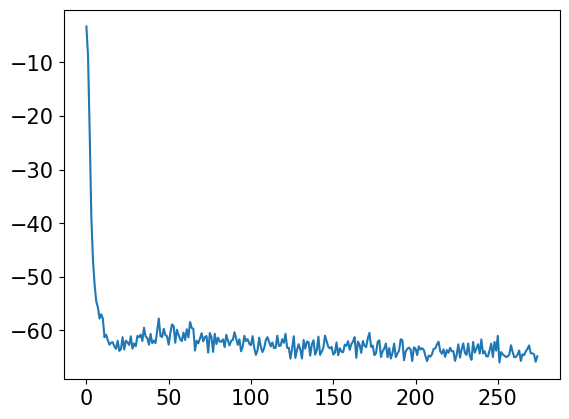

In [24]:
plt.plot(losses)

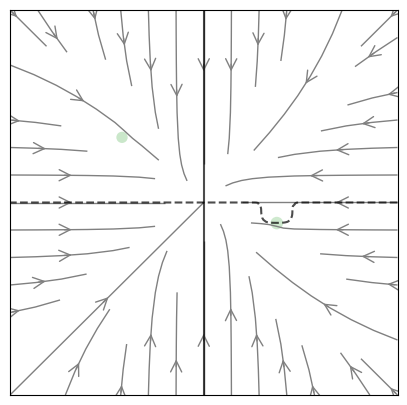

In [25]:
l = pytree.get_landscape()
fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')

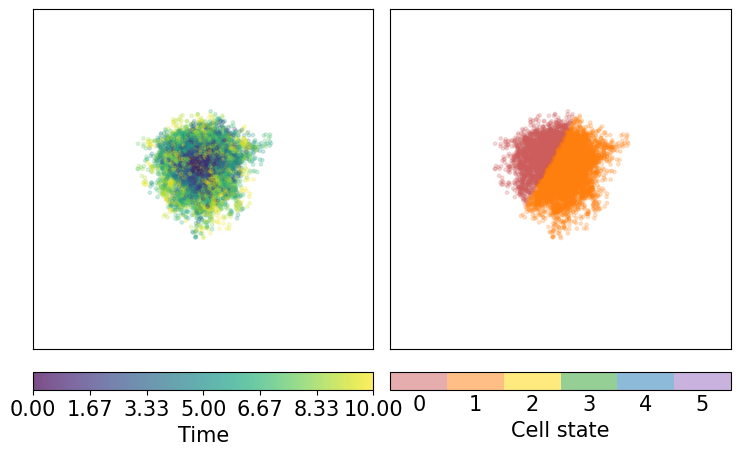

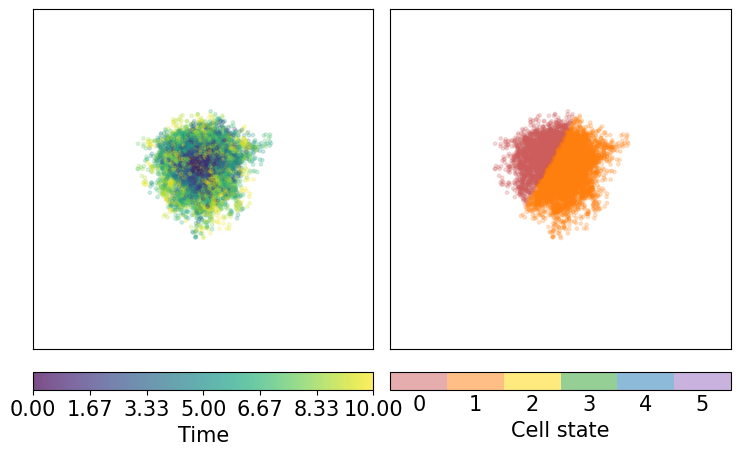

In [26]:
# Put back the coordinates of the cells at the init_ as the are
l.init_cells(n,static.init_cond,noise=cell_noise)
get_and_plot_traj(l,t0,tf,nt,L,noise) 

In [27]:
# n_frames = 100
# time_pars = (t0,tf, n_frames)
# print(l.n_regimes)
# labels = [f"regime {i}" for i in range(0,l.n_regimes+1)]
# print(labels)
# make_movie_discrete(l, xx, yy, labels, time_pars, n, noise, init_cond=l.init_cond,
#                         circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
#                         fps=10, save_dir='../figures/', filename='end_traj.gif')

# save_dir = '../figures/'
# import os, glob
# for f in glob.glob(save_dir + "frame_*.png"):
#     os.remove(f)

In [28]:
n_frames = steps//10
make_movie_landscape(pytree.dynamic_vals,static, xx, yy, n_frames)